In [20]:
import numpy as np
from astropy.table import Table
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.stats import binned_statistic
from scipy.optimize import curve_fit
import pickle

from astropy.cosmology import LambdaCDM
cosmo = LambdaCDM(70,0.3,0.7)

import sys
sys.path.insert(0,'../g3code/')
from g3misc import *

def multf_model(logN, a, b):
    return a*logN + b

In [41]:
df = Table.read('../catalogs/waves_g3_groups.fits').to_pandas()
meta = pickle.load(open('../catalogs/waves_g3_groups_footprint_meta.pkl','rb'))

In [42]:
halon = multiplicity_function(df.haloid, False)
grpn = multiplicity_function(df[df.grpid>0].grpid, False)

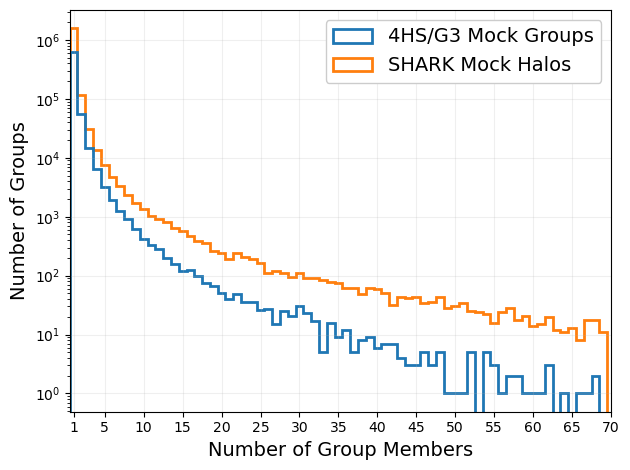

In [43]:
plt.figure()
histkwargs = dict(histtype='step', bins=np.arange(0.5,70.5,1), linewidth=2)
grpn_counts, _, _ = plt.hist(grpn,label='4HS/G3 Mock Groups', **histkwargs, zorder=1)
halon_counts, _, _ = plt.hist(halon, label='SHARK Mock Halos', **histkwargs, zorder=0)
plt.yscale('log')
plt.xlabel("Number of Group Members",fontsize=14)
plt.ylabel("Number of Groups", fontsize=14)
plt.xlim(histkwargs['bins'].min(), histkwargs['bins'].max())
#plt.axvline(5, color='k', label=r'$N=5$')
plt.legend(loc='upper right',framealpha=1, fontsize=14)
plt.gca().set_xticks([1]+list(np.arange(5,np.max(histkwargs['bins'])+1, 5)))
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("../figures/multf.png",dpi=300)
plt.show()

In [44]:
# xx = histkwargs['bins']
# xx = np.log10(0.5*(xx[1:]+xx[:-1]))

# popt_halo, pcov_halo = curve_fit(multf_model, xx, np.log10(halon_counts), p0=[6,0.04])
# popt_grp, pcov_grp = curve_fit(multf_model, xx, np.log10(grpn_counts))
# perr_halo = np.sqrt(np.diagonal(pcov_halo))
# perr_grp = np.sqrt(np.diagonal(pcov_grp))

# print(popt_halo, perr_halo)
# print(popt_grp, perr_grp)

# plt.figure(figsize=(4,4))
# plt.plot(xx, multf_model(xx, *popt_halo), color='tab:orange')
# plt.scatter(xx, np.log10(halon_counts), s=10, facecolor='None', edgecolor='tab:orange')
# plt.plot(xx, multf_model(xx, *popt_grp), color='tab:blue')
# plt.scatter(xx, np.log10(grpn_counts), s=10, facecolor='None', edgecolor='tab:blue')
# plt.ylim(0,6.5)
# plt.xlim(-0.03,2)
# plt.ylabel(r"log $n\left(N_{\rm galaxies}\right)$", fontsize=14)
# plt.xlabel(r"log $N_{\rm galaxies}$", fontsize=14)
# plt.tight_layout()
# plt.savefig("../figures/multF-linear.png",dpi=300)
# plt.show()

In [45]:
np.log10(halon_counts)

array([6.1985584 , 5.06585969, 4.48533806, 4.14072796, 3.87685265,
       3.67970038, 3.51587384, 3.36078269, 3.23729234, 3.13924922,
       3.01535976, 2.9571282 , 2.90254678, 2.80482068, 2.75204845,
       2.66745295, 2.59328607, 2.5563025 , 2.41995575, 2.38560627,
       2.28555731, 2.38738983, 2.31386722, 2.28555731, 2.22271647,
       2.04532298, 2.08278537, 2.0374265 , 1.96848295, 2.04532298,
       1.95424251, 1.96378783, 1.91907809, 1.88649073, 1.86923172,
       1.79239169, 1.78532984, 1.68124124, 1.78532984, 1.77815125,
       1.69897   , 1.50514998, 1.64345268, 1.62324929, 1.63346846,
       1.53147892, 1.54406804, 1.63346846, 1.44715803, 1.47712125,
       1.53147892, 1.39794001, 1.38021124, 1.34242268, 1.20411998,
       1.38021124, 1.44715803, 1.25527251, 1.32221929, 1.14612804,
       1.17609126, 1.30103   , 1.07918125, 1.04139269, 1.11394335,
       0.90308999, 1.25527251, 1.25527251, 1.04139269])

In [36]:
xx

NameError: name 'xx' is not defined

# Purity/completeness statistics

In [37]:
df.loc[:,'halon'] = multiplicity_function(df.haloid,True)
ra,dec,z = group_skycoords(df.ra, df.dec, df.redshift_cosmological, df.haloid)
df.loc[:,'halora'] = ra
df.loc[:,'halodec'] = dec
df.loc[:,'haloz'] = z

In [38]:
groups = df[df.grpid>0].groupby('grpid').first()
halos = df.groupby('haloid').first()

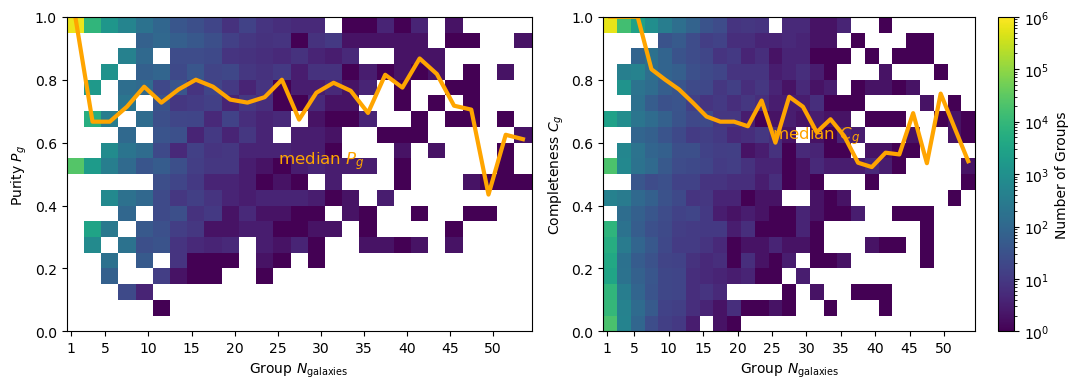

In [39]:
log_grpn = np.log10(groups.grpn)
bin2d = [np.arange(0.5,55.5,2),np.arange(0,1.05,0.05)]
norm = LogNorm(vmin=1e0,vmax=1e6)
linecol='orange'
lw=3

fig,axs=plt.subplots(ncols=2,figsize=(11,4))
axs[0].hist2d(groups.grpn, groups.Pg, norm=norm, bins=bin2d)
medianPg, binedges, _ = binned_statistic(groups.grpn, groups.Pg, bins=bin2d[0], statistic='median')
axs[0].plot(0.5*(binedges[:-1]+binedges[1:]), medianPg, color=linecol, linewidth=lw)
axs[0].set_ylabel("Purity $P_g$")
axs[0].annotate(xy=(25,0.53), text=r'median $P_g$', color='orange', fontsize=12)

hist2d=axs[1].hist2d(groups.grpn, groups.Cg, norm=norm, bins=bin2d)
medianCg, binedges, _ = binned_statistic(groups.grpn, groups.Cg, bins=bin2d[0], statistic='median')
axs[1].plot(0.5*(binedges[:-1]+binedges[1:]), medianCg, color=linecol, linewidth=lw)
axs[1].set_ylabel("Completeness $C_g$")
axs[1].annotate(xy=(25,0.61), text=r'median $C_g$', color='orange', fontsize=12)
cb=fig.colorbar(hist2d[-1])
cb.set_label("Number of Groups")

for ax in axs:
    ax.set_xlabel(r"Group $N_{\rm galaxies}$")
    ax.set_xticks([1]+list(np.arange(5,55,5)))
plt.tight_layout()
plt.savefig("../figures/Pg-Cg.png",dpi=300)
plt.show()

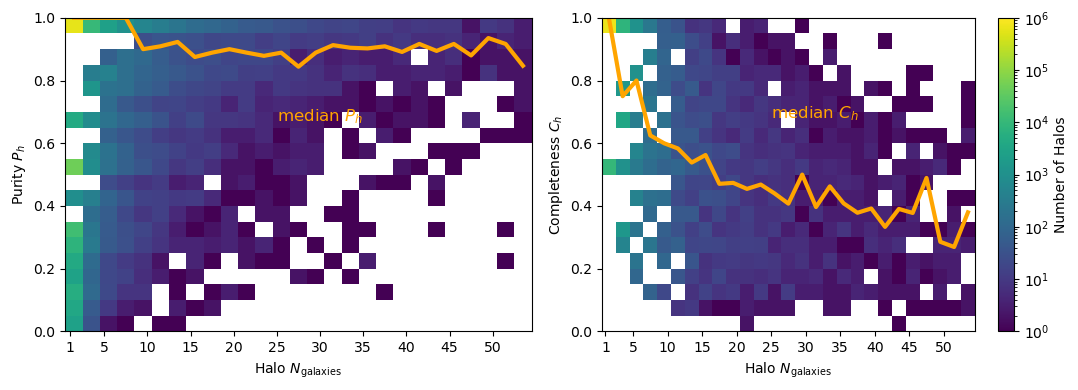

In [40]:
log_halon = np.log10(halos.halon)
bin2d = [np.arange(0.5,55.5,2),np.arange(0,1.05,0.05)]
norm = LogNorm(vmin=1e0,vmax=1e6)
linecol='orange'
lw=3

fig,axs=plt.subplots(ncols=2,figsize=(11,4))
axs[0].hist2d(halos.halon, halos.Ph, norm=norm, bins=bin2d)
medianPh, binedges, _ = binned_statistic(halos.halon, halos.Ph, bins=bin2d[0], statistic='median')
axs[0].plot(0.5*(binedges[:-1]+binedges[1:]), medianPh, color=linecol, linewidth=lw)
axs[0].set_ylabel("Purity $P_h$")
axs[0].annotate(xy=(25,0.67), text=r'median $P_h$', color='orange', fontsize=12)

hist2d=axs[1].hist2d(halos.halon, halos.Ch, norm=norm, bins=bin2d)
medianCh, binedges, _ = binned_statistic(halos.halon, halos.Ch, bins=bin2d[0], statistic='median')
axs[1].plot(0.5*(binedges[:-1]+binedges[1:]), medianCh, color=linecol, linewidth=lw)
axs[1].set_ylabel("Completeness $C_h$")
axs[1].annotate(xy=(25,0.68), text=r'median $C_h$', color='orange', fontsize=12)
cb=fig.colorbar(hist2d[-1])
cb.set_label("Number of Halos")

for ax in axs:
    ax.set_xlabel(r"Halo $N_{\rm galaxies}$")
    ax.set_xticks([1]+list(np.arange(5,55,5)))
plt.tight_layout()
plt.savefig("../figures/Ph-Ch.png",dpi=300)
plt.show()

In [11]:
medianCh

array([       nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        nan,
       1.        ,        nan,        nan, 0.97826087,        nan,
              nan,        nan,        nan, 0.77777778,        nan,
              nan, 0.53415916,        nan, 0.72533849,        nan,
              nan, 0.46481178])

In [13]:
medianPh

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,  1., nan, nan,
        1., nan, nan, nan, nan,  1., nan, nan,  1., nan,  1., nan, nan,
        1.])

# Group Centers

In [ ]:
plt.figure()
plt.scatter(df.redshift_cosmological, df.grpz-df.redshift_cosmological, alpha=0.5, s=1, rasterized=True)
plt.xlim(0,0.8)
plt.ylim(-0.02,0.02)
plt.show()

In [ ]:
fig, axs = plt.subplots(ncols=2, figsize=(11,4))
for ii,ax in enumerate(axs):

    cut = (groups.redshift_observed<0.3) if ii==0 else ((groups.redshift_observed>0.3))
    tmp = groups[cut & (groups.grpn>=2)]

    xx = tmp.redshift_cosmological
    yy = tmp.grpz-tmp.redshift_cosmological
    bin2d = [np.arange(tmp.redshift_cosmological.min(), tmp.redshift_cosmological.max(), 1e-2), np.arange(-0.005,0.005,0.0002)]
    hist2d = axs[ii].hist2d(xx, yy, bins=bin2d, norm=LogNorm(vmin=1, vmax=1000))

    print('global median: ', np.median(yy))
    median_dz, binedges, _ = binned_statistic(xx,yy, bins=bin2d[0], statistic='median')
    pt16, _, _ = binned_statistic(xx,yy,bins=bin2d[0],statistic=lambda x: np.percentile(x,16))
    pt84, _, _ = binned_statistic(xx,yy,bins=bin2d[0],statistic=lambda x: np.percentile(x,84))
    binc = 0.5*(binedges[1:]+binedges[:-1])
    ax.axhline(0,color='k',zorder=1)
    ax.plot(binc, median_dz, '.-', color='tab:red')
    ax.plot(binc, pt16, '--', color='tab:red')
    ax.plot(binc, pt84, '--', color='tab:red')
    
    ax.set_xlabel(r"Mock $z_{\rm cos}$", fontsize=14)
    ax.set_ylim(-0.004,0.004)
    ax.set_ylabel(r"$z_{\rm cos} - z_{\rm G3}$", fontsize=14)
cb = fig.colorbar(hist2d[-1], ax=axs[1])
plt.tight_layout()
plt.savefig("../figures/dz.png",dpi=300)
plt.show()

In [ ]:
lowz = df[df.footprint<=2]
dz=lowz.redshift_observed - lowz.redshift_cosmological
meddz = np.median(dz)
plt.figure()
plt.hist(dz, bins=100)
plt.axvline(meddz, color='k', label='median')
plt.yscale('log')
plt.xlabel(r"$z_{\rm obs} - z_{\rm cos}$", fontsize=14)
plt.annotate(xy=(0.1,0.8), xycoords='axes fraction', text='Subvolume 1', fontsize=12)
plt.show()
print(meddz * 3e5)
print(3e5*np.percentile(dz[lowz.grpn>=2].abs()/(1+0.15),50))

In [ ]:
highz = df[df.redshift_observed>0.35]
dz=highz.redshift_observed - highz.redshift_cosmological
meddz = np.median(dz)
plt.figure()
plt.hist(dz, bins=100, alpha=0.5)
plt.axvline(meddz, color='k', label='median')
#plt.yscale('log')
plt.xlabel(r"Mock $z_{\rm obs} - z_{\rm cos}$", fontsize=14)
plt.ylabel("Number of Galaxies", fontsize=14)
#plt.annotate(xy=(0.1,0.8), xycoords='axes fraction', text=r'High-$z$ Subvolume', fontsize=14)
plt.xlim(-0.008,0.008)
plt.tight_layout()
plt.savefig("../figures/highz-sv-vbias.png",dpi=300)
plt.show()

print(meddz, meddz * 3e5 / (1+np.median(highz.redshift_observed)))
print(3e5*np.percentile(dz[highz.grpn>=2].abs()/(1+0.5),50))

# Bijective comparison

In [ ]:
Nlimit = [10, 5, 4, 3, 2]
score = [0.1645, 0.1501, 0.1385, 0.1594, 0.1341]

In [ ]:
plt.figure()
plt.plot(Nlimit, score, 'ko-')
plt.ylabel("Bijective performance score")
plt.xlabel("Minimum group $N$ included")
plt.tight_layout()
plt.savefig("../figures/biject.png",dpi=300)
plt.show()